In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython import display
import pylab as pl

from visualization_utils import display_matrix, subplot_1D_signals
from bss_utils import generate_uncorrelated_uniform_sources, addWGN

# Helper Functions

In [2]:
@njit
def run_neural_dynamics(x, y,
                        W, L,
                        lambda_predictive,
                        neural_lr_start,
                        neural_lr_stop,
                        neural_OUTPUT_COMP_TOL=1e-7,):
    yke = np.dot(W, x)
    L_diag = np.diag(L)
    L_off_diag = L - np.diag(L_diag)
    for j in range(neural_dynamics_iterations):
        mu_y = max(neural_lr_start / (j + 1), neural_lr_stop)
        y_old = y.copy()
        error = y - yke
        lateral = np.dot(L_off_diag, y) + 2 * np.dot(np.diag(1 / L_diag), y)
        grady = lambda_predictive * error - lateral
        y = y - mu_y * grady
        y = np.clip(y, -1, 1)
        if np.linalg.norm(y - y_old) < neural_OUTPUT_COMP_TOL * np.linalg.norm(y):
            break
    return y
    
@njit(parallel=True)
def snr_jit(S_original, S_noisy):
    N_hat = S_original - S_noisy
    N_P = (N_hat**2).sum(axis=1)
    S_P = (S_original**2).sum(axis=1)
    snr = 10 * np.log10(S_P / N_P)
    return snr
        
def outer_prod_broadcasting(A, B):
        """Broadcasting trick."""
        return A[..., None] * B[:, None]
    
def find_permutation_between_source_and_estimation( S, Y):
    """
    S    : Original source matrix
    Y    : Matrix of estimations of sources (after BSS or ICA algorithm)

    return the permutation of the source seperation algorithm
    """
    # perm = np.argmax(np.abs(self.outer_prod_broadcasting(Y,S).sum(axis = 0))/(np.linalg.norm(S,axis = 0)*np.linalg.norm(Y,axis=0)), axis = 0)
    perm = np.argmax(
        np.abs(outer_prod_broadcasting(Y.T, S.T).sum(axis=0))
        / (np.linalg.norm(S, axis=1) * np.linalg.norm(Y, axis=1)),
        axis=0,
    )
    return perm

def signed_and_permutation_corrected_sources( S, Y):
    """_summary_

    Args:
        S (_type_): _description_
        Y (_type_): _description_

    Returns:
        _type_: _description_
    """
    perm = find_permutation_between_source_and_estimation(S, Y)
    return (np.sign((Y[perm, :] * S).sum(axis=1))[:, np.newaxis]) * Y[perm, :]
    
def compute_overall_mapping(W, L, lambda_predictive):
    I = np.eye(*L.shape)
    W_ = np.linalg.solve(lambda_predictive * I - L, W)
    return W_

@njit
def CalculateSINRjit(Out, S, compute_permutation=True):
    def mean_numba(a):
        res = []
        for i in range(a.shape[0]):
            res.append(a[i, :].mean())

        return np.array(res)

    r = S.shape[0]
    Smean = mean_numba(S)
    Outmean = mean_numba(Out)
    if compute_permutation:
        G = np.dot(
            Out - np.reshape(Outmean, (r, 1)),
            np.linalg.pinv(S - np.reshape(Smean, (r, 1))),
        )
        # G = np.linalg.lstsq((S-np.reshape(Smean,(r,1))).T, (Out-np.reshape(Outmean,(r,1))).T)[0]
        indmax = np.abs(G).argmax(1).astype(np.int64)
    else:
        G = np.dot(
            Out - np.reshape(Outmean, (r, 1)),
            np.linalg.pinv(S - np.reshape(Smean, (r, 1))),
        )
        # G = np.linalg.lstsq((S-np.reshape(Smean,(r,1))).T, (Out-np.reshape(Outmean,(r,1))).T)[0]
        indmax = np.arange(0, r)

    GG = np.zeros((r, r))
    for kk in range(r):
        GG[kk, indmax[kk]] = np.dot(
            Out[kk, :] - Outmean[kk], S[indmax[kk], :].T - Smean[indmax[kk]]
        ) / np.dot(
            S[indmax[kk], :] - Smean[indmax[kk]],
            S[indmax[kk], :].T - Smean[indmax[kk]],
        )  # (G[kk,indmax[kk]])

    ZZ = GG @ (S - np.reshape(Smean, (r, 1))) + np.reshape(Outmean, (r, 1))
    E = Out - ZZ
    MSE = np.linalg.norm(E) ** 2
    SigPow = np.linalg.norm(ZZ) ** 2
    SINR = SigPow / MSE
    return SINR, SigPow, MSE, G

def WSM_Mixing_Scenario(S, NumberofMixtures=None, INPUT_STD=None):
    NumberofSources = S.shape[0]
    if INPUT_STD is None:
        INPUT_STD = S.std()
    if NumberofMixtures is None:
        NumberofMixtures = NumberofSources
    A = np.random.standard_normal(size=(NumberofMixtures, NumberofSources))
    X = A @ S
    for M in range(A.shape[0]):
        stdx = np.std(X[M, :])
        A[M, :] = A[M, :] / stdx * INPUT_STD
    X = A @ S
    return A, X

# Generate Sources and Mix Them (2 by 2 case)

In [3]:
np.random.seed(50)
N = 100000
NumberofSources = 2
NumberofMixtures = NumberofSources

S = generate_uncorrelated_uniform_sources(NumberofSources, N)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
# A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)

A, X_noNoise = WSM_Mixing_Scenario(S, NumberofMixtures)

SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.97620905815717


(array([0.3325294 , 0.33533597]), array([0.33430207, 0.33432277]))

# Hyperparameters

In [4]:
L = 1*np.eye(NumberofSources)
W = np.eye(NumberofSources, NumberofMixtures)

# L = np.abs(np.diag(np.diag(np.random.randn(NumberofSources, NumberofSources)))) 
# W = np.random.randn(NumberofSources, NumberofMixtures)

lambda_predictive = 100
muW = 30 * 1e-3
synaptic_lr_decay_divider=5000
lambdaL = 1 - 0.00001

neural_lr_start = 0.9
neural_lr_stop = 1e-6
neural_dynamics_iterations = 100
debug_iteration_point = 10000

In [5]:
L

array([[1., 0.],
       [0., 1.]])

In [6]:
samples = N
idx = np.random.permutation(samples)  # random permutation
for i_sample in tqdm(range(samples)):
    if ((i_sample % debug_iteration_point) == 0) | (
                        i_sample == samples - 1
                    ):
        Wf = compute_overall_mapping(W, L, lambda_predictive)
        Y_ = Wf @ X
        Y_ = signed_and_permutation_corrected_sources(S, Y_)
        coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
        Y_ = coef_ * Y_
        SINR = 10 * np.log10(CalculateSINRjit(Y_, S, False)[0])
        print("SINR: {}".format(SINR))
        print("Component SNR Values : {}\n".format(snr_jit(S, Y_)))
    x_current = X[:, idx[i_sample]]
    y = np.zeros(NumberofSources)

    y = run_neural_dynamics(x_current, y, W, L, lambda_predictive, neural_lr_start, neural_lr_stop)
    e = y - W @ x_current
    muW_ = np.max(
                [
                    muW
                    / (1 + np.log(2 + (i_sample // synaptic_lr_decay_divider))),
                    1e-8,
                ]
            )

    W = W + muW_ * np.outer(e, x_current)
    L = lambdaL * L + (1 - lambdaL) * np.outer(y, y)

  0%|          | 0/100000 [00:00<?, ?it/s]

SINR: 7.453164338122136
Component SNR Values : [13.63496868  5.22544391]



/tmp/ipykernel_4117635/4153628807.py:8: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  yke = np.dot(W, x)
 11%|█         | 11022/100000 [00:12<00:21, 4048.15it/s]

SINR: 9.476746361136858
Component SNR Values : [19.36334835  6.71154816]



 22%|██▏       | 21963/100000 [00:13<00:07, 10952.40it/s]

...

SINR: 26.887337184110276
Component SNR Values : [28.13619601 25.9391654 ]



 92%|█████████▏| 91794/100000 [00:19<00:00, 12167.92it/s]

SINR: 26.845867660268826
Component SNR Values : [28.22409056 25.82209704]



100%|██████████| 100000/100000 [00:19<00:00, 5045.08it/s]

SINR: 26.82707729538077
Component SNR Values : [28.04011256 25.90068554]



In [7]:
y, e, x_current

(array([ 0.14259045, -0.04585902]),
 array([ 0.00452121, -0.0015469 ]),
 array([ 0.12608587, -0.0980875 ]))

In [8]:
W, L

(array([[1.34177048, 0.31714751],
        [0.87208584, 1.57278056]]),
 array([[ 0.6331158 , -0.03675137],
        [-0.03675137,  0.61369737]]))

In [9]:
S.var(1)

array([0.3325294 , 0.33533597])

In [10]:
X.var(1)

array([0.33430207, 0.33432277])

In [11]:
# Wf = compute_overall_mapping(W, L, lambda_predictive)
Y = W @ X
Y_ = signed_and_permutation_corrected_sources(S, Y)
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
Y_ = coef_ * Y_

print("Component SNR Values : {}\n".format(snr_jit(S, Y_)))

SINR = 10 * np.log10(CalculateSINRjit(Y_, S)[0])

print("Overall SINR : {}".format(SINR))

Component SNR Values : [28.05760316 25.90791542]

Overall SINR : 26.838201798289898


In [12]:
coef_

array([[0.87492209],
       [0.88102534]])

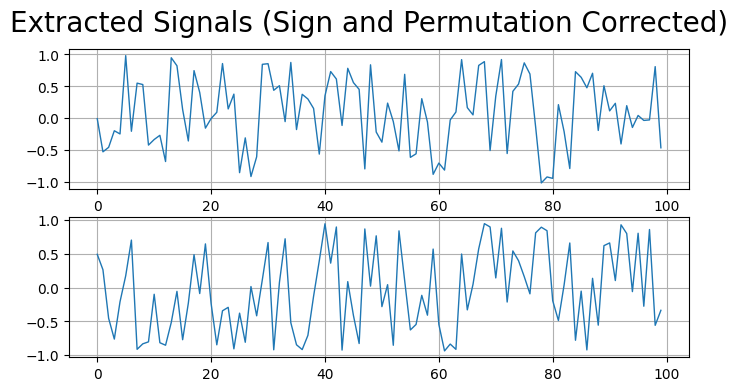

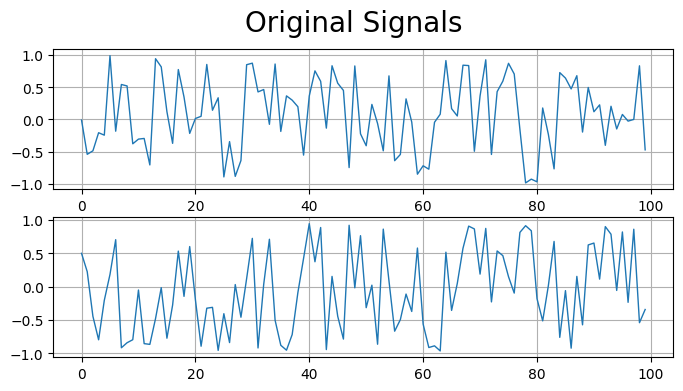

In [13]:
subplot_1D_signals(
    Y_[:, 0:100],
    title="Extracted Signals (Sign and Permutation Corrected)",
    figsize=(8, 4),
    colorcode=None,
)
subplot_1D_signals(
    S[:, 0:100], title="Original Signals", figsize=(8, 4), colorcode=None
)